# Skin Lesion Classification with CNN
### 204466 Deep Learning — Final Project
**Dataset:** HAM10000 (Human Against Machine with 10000 training images)  
**Task:** Multi-class skin lesion classification (7 classes)  
**Architecture:** Custom CNN with class imbalance handling

## 1. Setup & Mount Google Drive

In [5]:
!pip install kaggle -q

from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/skin_lesion/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/skin_lesion/


## 2. Download Dataset

In [6]:
import os
os.environ["KAGGLE_USERNAME"] = "thanutham"
os.environ["KAGGLE_KEY"] = "KGAT_b1350be88c0d761b73bdb8b5750fc6ad"


!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000

import zipfile
with zipfile.ZipFile('/content/ham10000/skin-cancer-mnist-ham10000.zip', 'r') as z:
    z.extractall('/content/ham10000')

print('Dataset ready!')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:33<00:00, 164MB/s]

Dataset ready!


## 3. Import Libraries

In [7]:
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 4. Data Exploration & Preparation

Total samples: 10015


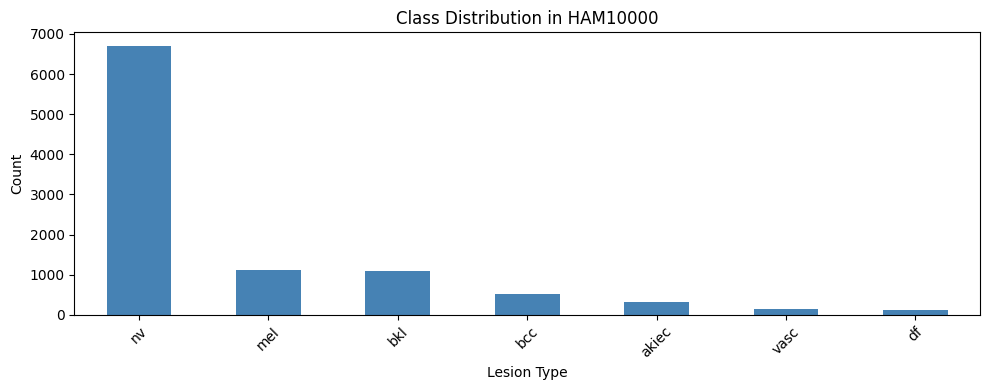

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [8]:
label_map = {
    'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3,
    'akiec': 4, 'vasc': 5, 'df': 6
}
class_names = list(label_map.keys())

metadata = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')
metadata['label'] = metadata['dx'].map(label_map)
print(f'Total samples: {len(metadata)}')

plt.figure(figsize=(10, 4))
metadata['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution in HAM10000')
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_distribution.png', dpi=150)
plt.show()
print(metadata['dx'].value_counts())

In [9]:
image_paths = {}
for folder in ['/content/ham10000/HAM10000_images_part_1',
               '/content/ham10000/HAM10000_images_part_2']:
    for img_path in glob.glob(os.path.join(folder, '*.jpg')):
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        image_paths[img_id] = img_path

metadata['path'] = metadata['image_id'].map(image_paths)
metadata = metadata.dropna(subset=['path'])
print(f'Images found: {len(metadata)}')

Images found: 10015


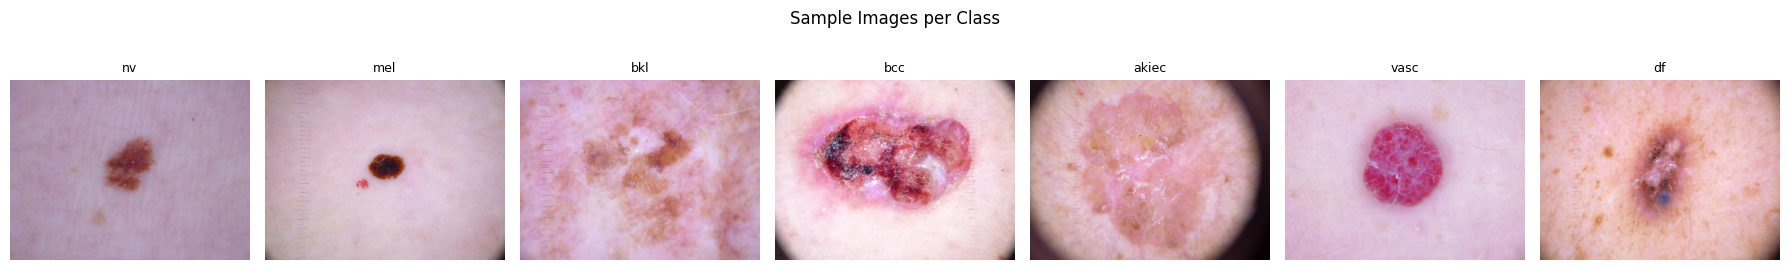

In [10]:
fig, axes = plt.subplots(1, 7, figsize=(18, 3))
for i, cls in enumerate(class_names):
    sample = metadata[metadata['dx'] == cls].iloc[0]
    axes[i].imshow(Image.open(sample['path']))
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Sample Images per Class')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'sample_images.png', dpi=150)
plt.show()

In [11]:
train_df, temp_df = train_test_split(metadata, test_size=0.30, stratify=metadata['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 7010 | Val: 1502 | Test: 1503


## 5. Dataset & DataLoader

In [12]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

In [13]:
IMG_SIZE   = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.763, 0.546, 0.570], std=[0.141, 0.152, 0.169])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.763, 0.546, 0.570], std=[0.141, 0.152, 0.169])
])

train_dataset = SkinLesionDataset(train_df, transform=train_transform)
val_dataset   = SkinLesionDataset(val_df,   transform=val_transform)
test_dataset  = SkinLesionDataset(test_df,  transform=val_transform)

class_counts   = train_df['label'].value_counts().sort_index().values
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 220 | Val: 47 | Test: 47


## 6. CNN Model Architecture

Custom CNN:
- 4 ConvBlocks: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
- Filters: 32 → 64 → 128 → 256
- Global Average Pooling
- FC: 256 → 128 → 7

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout)
        )
    def forward(self, x):
        return self.block(x)


class SkinLesionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  dropout=0.25),
            ConvBlock(32,  64,  dropout=0.25),
            ConvBlock(64,  128, dropout=0.25),
            ConvBlock(128, 256, dropout=0.40),
        )
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        return self.classifier(x)


model = SkinLesionCNN(num_classes=7).to(device)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Total parameters: 1,207,975
SkinLesionCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.25, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

## 7. Loss, Optimizer & Scheduler

In [15]:
weights   = torch.tensor(class_weights / class_weights.sum() * len(class_weights), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print('Loss     : CrossEntropyLoss (class-weighted)')
print('Optimizer: Adam (lr=1e-3, weight_decay=1e-4)')
print('Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)')

Loss     : CrossEntropyLoss (class-weighted)
Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


## 8. Training Loop

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, correct / total

In [17]:
NUM_EPOCHS    = 30
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_DIR + 'best_model.pth')

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

print(f'\nDone! Best model saved to {SAVE_DIR}best_model.pth')

Epoch [01/30]  Train Loss: 1.3920  Train Acc: 0.2238  Val Loss: 2.4202  Val Acc: 0.0213
Epoch [02/30]  Train Loss: 1.1902  Train Acc: 0.2628  Val Loss: 2.1738  Val Acc: 0.0379
Epoch [03/30]  Train Loss: 1.1366  Train Acc: 0.2797  Val Loss: 2.2252  Val Acc: 0.0373
Epoch [04/30]  Train Loss: 1.1328  Train Acc: 0.2749  Val Loss: 2.0307  Val Acc: 0.0306
Epoch [05/30]  Train Loss: 1.0725  Train Acc: 0.3046  Val Loss: 2.1198  Val Acc: 0.0752
Epoch [06/30]  Train Loss: 1.0219  Train Acc: 0.3121  Val Loss: 2.1074  Val Acc: 0.0499
Epoch [07/30]  Train Loss: 1.0515  Train Acc: 0.2959  Val Loss: 2.0927  Val Acc: 0.0632
Epoch [08/30]  Train Loss: 1.0441  Train Acc: 0.3058  Val Loss: 1.8967  Val Acc: 0.0919
Epoch [09/30]  Train Loss: 1.0122  Train Acc: 0.3060  Val Loss: 2.3919  Val Acc: 0.0393
Epoch [10/30]  Train Loss: 1.0291  Train Acc: 0.3064  Val Loss: 1.9991  Val Acc: 0.0606
Epoch [11/30]  Train Loss: 0.9810  Train Acc: 0.3287  Val Loss: 1.9710  Val Acc: 0.0932
Epoch [12/30]  Train Loss: 1.001

## 9. Training Curves

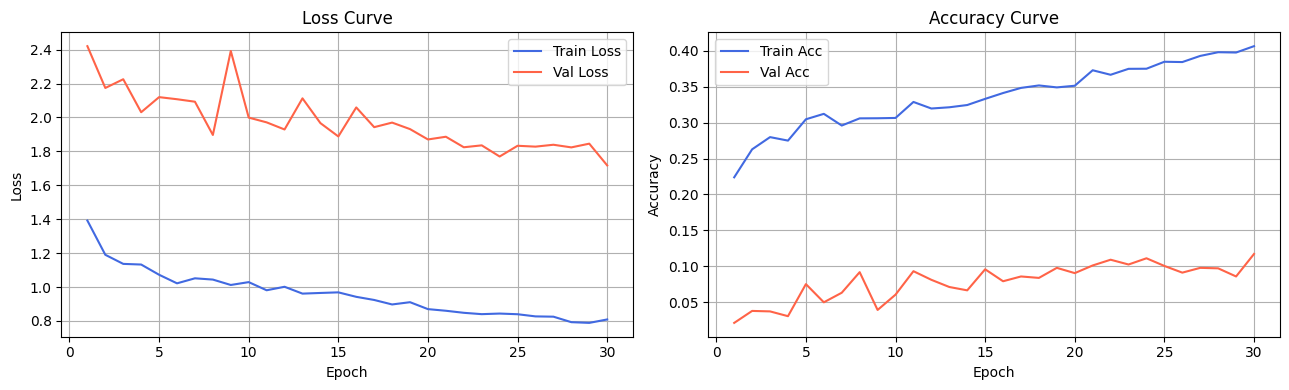

In [18]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss Curve'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history['train_acc'], label='Train Acc', color='royalblue')
ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy Curve'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'training_curves.png', dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [19]:
model.load_state_dict(torch.load(SAVE_DIR + 'best_model.pth', map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Loss    : 1.7325
Test Accuracy: 0.1111 (11.11%)


In [20]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

          nv       0.00      0.00      0.00      1006
         mel       0.21      0.55      0.30       167
         bkl       0.00      0.00      0.00       165
         bcc       0.19      0.18      0.19        77
       akiec       0.16      0.65      0.25        49
        vasc       0.20      0.91      0.33        22
          df       0.01      0.53      0.03        17

    accuracy                           0.11      1503
   macro avg       0.11      0.40      0.16      1503
weighted avg       0.04      0.11      0.06      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


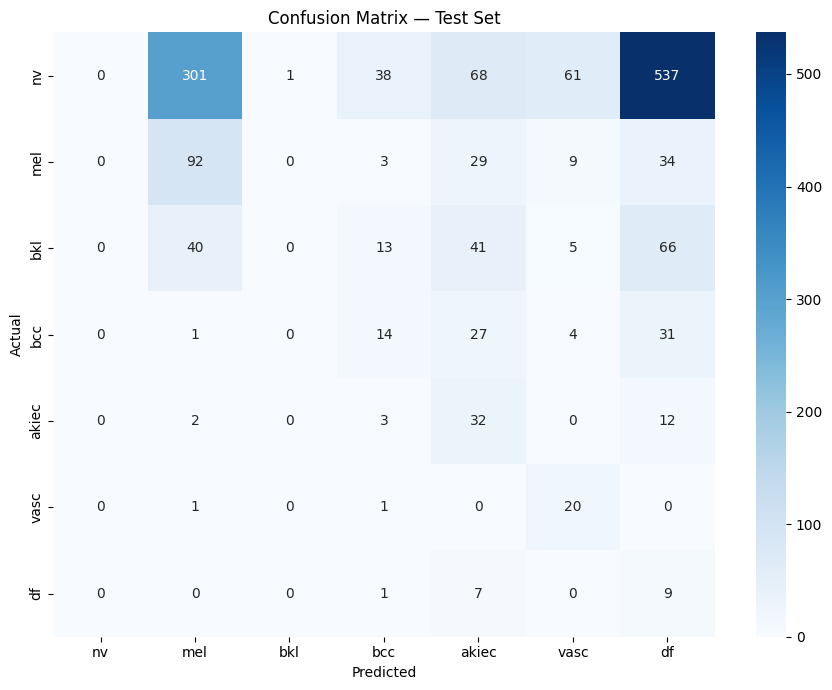

In [21]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix.png', dpi=150)
plt.show()

## 11. Visualize Predictions

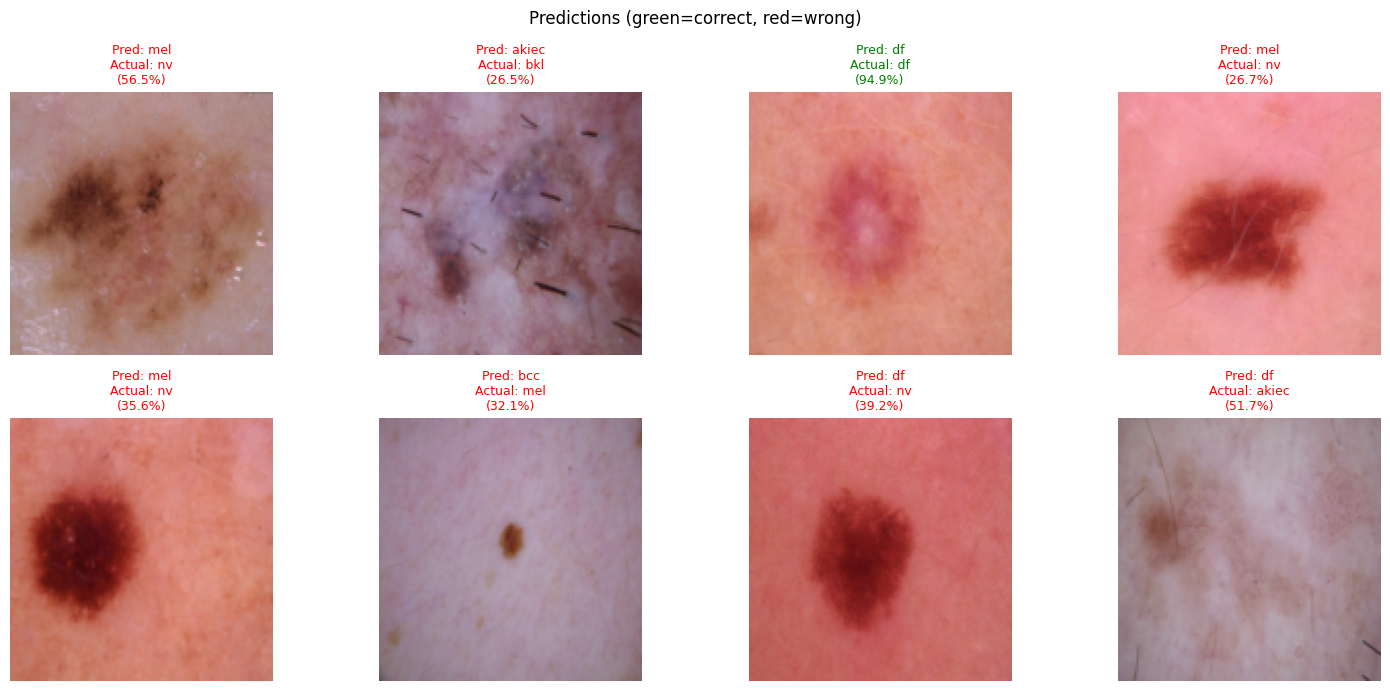

In [22]:
inv_normalize = transforms.Normalize(
    mean=[-0.763/0.141, -0.546/0.152, -0.570/0.169],
    std=[1/0.141, 1/0.152, 1/0.169]
)

model.eval()
sample_images, sample_labels = next(iter(test_loader))
with torch.no_grad():
    outputs = model(sample_images.to(device))
    probs   = F.softmax(outputs, dim=1)
    preds   = outputs.max(1)[1]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    img        = inv_normalize(sample_images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    actual     = class_names[sample_labels[i]]
    predicted  = class_names[preds[i].item()]
    confidence = probs[i][preds[i]].item()
    ax.imshow(img)
    ax.set_title(f'Pred: {predicted}\nActual: {actual}\n({confidence:.1%})',
                 color='green' if actual == predicted else 'red', fontsize=9)
    ax.axis('off')

plt.suptitle('Predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'predictions.png', dpi=150)
plt.show()

## 12. Save Results for Comparison

In [23]:
results = {
    'model'   : 'Custom CNN (SkinLesionCNN)',
    'accuracy' : float(test_acc),
    'precision': float(precision_score(all_labels, all_preds, average='weighted', zero_division=0)),
    'recall'   : float(recall_score(all_labels,    all_preds, average='weighted', zero_division=0)),
    'f1'       : float(f1_score(all_labels,         all_preds, average='weighted', zero_division=0)),
    'per_class_f1': {
        class_names[i]: float(f)
        for i, f in enumerate(f1_score(all_labels, all_preds, average=None, zero_division=0))
    }
}

with open(SAVE_DIR + 'cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Results saved to {SAVE_DIR}cnn_results.json')
print(f'  Accuracy : {results["accuracy"]:.4f}')
print(f'  Precision: {results["precision"]:.4f}')
print(f'  Recall   : {results["recall"]:.4f}')
print(f'  F1       : {results["f1"]:.4f}')

Results saved to /content/drive/MyDrive/skin_lesion/cnn_results.json
  Accuracy : 0.1111
  Precision: 0.0414
  Recall   : 0.1111
  F1       : 0.0568


## Summary

| Component | Detail |
|-----------|--------|
| **Dataset** | HAM10000 — 10,015 dermoscopy images, 7 classes |
| **Architecture** | Custom CNN: 4 ConvBlocks + Global Avg Pool + FC |
| **Imbalance handling** | WeightedRandomSampler + Weighted CrossEntropyLoss |
| **Augmentation** | Flip, Rotate, ColorJitter |
| **Optimizer** | Adam (lr=1e-3, wd=1e-4) |
| **Scheduler** | ReduceLROnPlateau |
| **Epochs** | 30 |
| **Input size** | 128×128 RGB |